## Topic: Parallel Workflow in LangGraph

### Agenda:
- 1. Introduction of Parallel Workflow

- 2. Reducers — Merging Parallel Results

- 3. A Simple Example Without LLM

- 4. When to Use Parallel Workflows

- 5. Key Takeaways

### 1. Introduction of Parallel Workflow
- Definition:
    - A Parallel Workflow is a graph pattern where multiple nodes execute at the same time instead of one after another. The results are then combined (merged) into a single state.

- Main idea: 
    - Parallel workflows split work into independent branches that run simultaneously, then merge the results. Use them when steps don't depend on each other.

In [ ]:
""" 
Sequential (One at a time):
  A → B → C → D → END
  Total time: 4 seconds (if each takes 1 sec)

Parallel (All at once):
       ┌→ B →┐
  A →  ├→ C →├→ E → END
       └→ D →┘
  Total time: 2 seconds (B, C, D run simultaneously)

"""

"""         - Sequential vs Parallel — The Speed Problem

┌─────────────────────────────────────────────────────────────┐
│           THE LATENCY PROBLEM                               │
│                                                             │
│  Task: "Research a topic from 3 sources and write a report" │
│                                                             │
│  SEQUENTIAL APPROACH:                                       │
│  ────────────────────                                       │
│  Search Web (2s) → Search DB (1s) → Search PDF (1.5s)       │
│  → Combine (0.5s) → Write Report (3s)                       │
│  Total: 8 seconds                                           │
│                                                             │
│  PARALLEL APPROACH:                                         │
│  ──────────────────                                         │
│  ┌ Search Web  (2s)   ──┐                                   │
│  ├ Search DB   (1s)   ──├→ Combine (0.5s) → Report (3s)     │
│  └ Search PDF  (1.5s) ──┘                                   │
│  Total: 5.5 seconds  (31% faster!)                          │
│                                                             │
│  The parallel branch takes as long as the SLOWEST task,     │
│  not the SUM of all tasks.                                  │
│                                                             │
│  Parallel time = max(branch_times) + merge_time             │
│  Sequential time = sum(all_times)                           │
└─────────────────────────────────────────────────────────────┘

"""

In [ ]:
"""
- Why Use Parallel Workflows?:
 ============================

┌─────────────────────────────────────────────────────────────┐
│           WHY PARALLEL?                                     │
│                                                             │
│  1. SPEED                                                   │
│     Run independent tasks at the same time.                 │
│     3 API calls in 1 second instead of 3 seconds.           │
│                                                             │
│  2. MULTI-SOURCE DATA                                       │
│     Search the web, your database, AND your vector store    │
│     at the same time. Combine the best results.             │
│                                                             │
│  3. ENSEMBLE / VOTING                                       │
│     Ask 3 different LLMs the same question.                 │
│     Take the majority answer for higher accuracy.           │
│                                                             │
│  4. INDEPENDENT SUB-TASKS                                   │
│     Analyze sentiment, extract entities, and summarize      │
│     a document — all at once. They don't need each other.   │
│                                                             │
│  5. REAL-WORLD LATENCY REQUIREMENTS                         │
│     Users expect responses in < 2 seconds.                  │
│     Sequential LLM calls add up. Parallel keeps it fast.    │
└─────────────────────────────────────────────────────────────┘

"""

### 2. Reducers — Merging Parallel Results

In [ ]:
"""
┌─────────────────────────────────────────────────────────────┐
│           STATE MERGING IN PARALLEL GRAPHS                  │
│                                                             │
│  Scenario: 3 branches write to state["results"]             │
│                                                             │
│  WITHOUT REDUCER (default = overwrite):                     │
│  ──────────────────────────────────────                     │
│  Branch A: {"results": ["A"]}                               │
│  Branch B: {"results": ["B"]}                               │
│  Branch C: {"results": ["C"]}                               │
│  Final:    {"results": ["C"]}   ← Only last one survives!   │
│  ❌ Data loss!                                             │
│                                                            │
│  WITH REDUCER (operator.add):                              │
│  ─────────────────────────────                             │
│  Branch A: {"results": ["A"]}                              │
│  Branch B: {"results": ["B"]}                              │
│  Branch C: {"results": ["C"]}                              │
│  Final:    {"results": ["A", "B", "C"]}  ← All combined!   │
│  ✅ No data loss!                                          │
│                                                             │
│  IMPORTANT NOTES:                                           │
│  • The ORDER of merged results is NOT guaranteed            │
│    (branches finish at different times)                     │
│  • Each branch should return a LIST with its results        │
│  • The reducer appends lists together                       │
│  • Use Annotated[list, operator.add] in your State          │
└─────────────────────────────────────────────────────────────┘

"""

In [ ]:
""" 

┌─────────────────────────────────────────────────────────────┐
│           ERROR HANDLING IN PARALLEL GRAPHS                 │
│                                                             │
│  What happens when ONE branch fails?                        │
│                                                             │
│  Default: The ENTIRE graph fails if ANY branch errors.      │
│                                                             │
│  ┌──→ Branch A ✅ ──┐                                       │
│  ├──→ Branch B ❌ ──┼──→ MERGE ⛔ (graph stops!)           │
│  └──→ Branch C ✅ ──┘                                      │
│                                                             │
│  Best Practices:                                            │
│  1. Wrap each branch in try/except                          │
│  2. Return error info in state instead of crashing          │
│  3. Let the merge node handle missing/partial results       │
│                                                             │
│  Example:                                                   │
│  def safe_branch(state):                                    │
│      try:                                                   │
│          result = risky_api_call()                          │
│          return {"results": [result]}                       │
│      except Exception as e:                                 │
│          return {"results": [f"ERROR: {e}"]}  # Don't crash │
└─────────────────────────────────────────────────────────────┘

"""

In [ ]:
""" 
- Syntax or pattern:
=======================

from langgraph.graph import StateGraph, START, END

graph = StateGraph(MyState)

graph.add_node("split", split_node)
graph.add_node("branch_1", branch_1_node)
graph.add_node("branch_2", branch_2_node)
graph.add_node("branch_3", branch_3_node)
graph.add_node("merge", merge_node)

# Fan-out: split → all branches (PARALLEL!)
graph.add_edge(START, "split")
graph.add_edge("split", "branch_1")   # ← All three run
graph.add_edge("split", "branch_2")   #   at the same
graph.add_edge("split", "branch_3")   #   time!

# Fan-in: all branches → merge
graph.add_edge("branch_1", "merge")   # ← Merge waits for
graph.add_edge("branch_2", "merge")   #   ALL branches
graph.add_edge("branch_3", "merge")   #   to finish

graph.add_edge("merge", END)


=========================================

  START → split ──┬──→ branch_1 ──┐
                  ├──→ branch_2 ──┼──→ merge → END
                  └──→ branch_3 ──┘
                  (parallel)      (waits for all)

"""

### 3. A Simple Example Without LLM

In [ ]:
"""
Problem Statement: Parallel Prediction and analysis of cricket batsman performance
───────────────────────────────────────────────────────────────────────────────────
Flow:
  START → input ──┬──→ SR  ──┐
                  ├──→ BPB ──┼──→ summary → END
                  └──→ BP  ──┘

Analyze of cricket batsman Performance

- Strike Rate (SR)
- boundary per ball(BPB)
- boundary percentage(BP)
- summary of the player

all at the same time from the same input text.

- why use Parallel:
  - Because, where SR, BPB and BP are independent that way we use the parallel workflow

- For this Problem are the state:
  - runs, balls, 4s, 6s 
  - sr, bpb, bp, summary
"""

In [1]:
# import libraries
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

#### 1. Define State

In [2]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    bp: float

    summary: str

#### 3. Create nodes

In [13]:
# nodes for Calculate Strick rate
# formula of Strick rate: (runs/balls)*100

def Calculate_Sr(state:BatsmanState) -> dict:
    # Extract the runs and balls from BatsmanState
    runs = state["runs"]
    balls = state["balls"]

    # Partial Update 
    sr = (runs/balls)*100

    # state["sr"] = (state["runs"]/state["balls"]) * 100

    # return the dict 
    return {"sr": sr}

In [14]:
# nodes for Calculate boundary per ball
# formula of boundary per ball: (balls/fours + sixes)

def Calculate_Bpb(state:BatsmanState) -> dict:

    bpb = (state["balls"]/state["fours"] + state["sixes"])

    # return the dict 
    return {"bpb": bpb}

In [15]:
# nodes for Calculate boundary per ball
# formula of boundary Percentage: (((fours * 4) + (sixes * 6)) / runs) *100

def Calculate_Bp(state:BatsmanState) -> dict:

    bp = ( ((state["fours"] * 4) + (state["sixes"]*6))/state["runs"] * 100)

    # return the dict 
    return {"bp": bp}

In [16]:
# nodes for Calculate boundary per ball
# formula of boundary Percentage: (((fours * 4) + (sixes * 6)) / runs) *100

def Summary(state:BatsmanState) -> dict:

    summary = f""" 
    Strick rate - {state['sr']}\n
    boundary per ball - {state['bpb']}\n
    boundary Percentage - {state['bp']}
    """


    # return the dict 
    return {"summary": summary}

#### 2. Create a Graph

In [17]:
graph = StateGraph(BatsmanState)

# nodes
graph.add_node("Calculate_Sr", Calculate_Sr)
graph.add_node("Calculate_Bpb", Calculate_Bpb)
graph.add_node("Calculate_Bp", Calculate_Bp)
graph.add_node("Summary", Summary)


# edges __ Parallel connection
graph.add_edge(START, "Calculate_Sr")
graph.add_edge(START, "Calculate_Bpb")
graph.add_edge(START, "Calculate_Bp")

graph.add_edge("Calculate_Sr", "Summary")
graph.add_edge("Calculate_Bpb", "Summary")
graph.add_edge("Calculate_Bp", "Summary")

graph.add_edge("Summary", END)


# compile
workflow = graph.compile()

print(workflow)

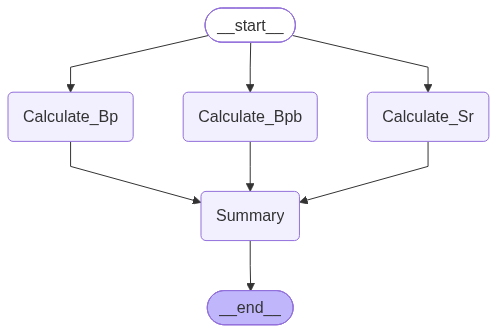

In [18]:
graph.compile()

#### 4. Execute

In [25]:
initial_state = {
    "runs": 75,
    "balls": 71,
    "fours": 7,
    "sixes": 0
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 75, 'balls': 71, 'fours': 7, 'sixes': 0, 'sr': 105.63380281690141, 'bpb': 10.142857142857142, 'bp': 37.333333333333336, 'summary': ' \n    Strick rate - 105.63380281690141\n\n    boundary per ball - 10.142857142857142\n\n    boundary Percentage - 37.333333333333336\n    '}


In [22]:
intial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

final_state = workflow.invoke(intial_state)

print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 12.333333333333334, 'bp': 48.0, 'summary': ' \n    Strick rate - 200.0\n\n    boundary per ball - 12.333333333333334\n\n    boundary Percentage - 48.0\n    '}


### 4. When to Use Parallel Workflows

In [ ]:
""" 
┌─────────────────────────────────────────────────────────────┐
│           USE PARALLEL WHEN...                              │
│                                                             │
│  -  Branches are INDEPENDENT                                │
│     Branch B does not need Branch A's output.               │
│     Example: Search 3 different APIs                        │
│                                                             │
│  -  You need SPEED                                          │
│     Multiple LLM calls or API requests add up.              │
│     Parallel cuts latency to the slowest branch.            │
│                                                             │
│  -  You are aggregating from MULTIPLE SOURCES               │
│     Web + Database + Vector Store → combine best results.   │
│                                                             │
│  -  You want ENSEMBLE / VOTING                              │
│     Multiple LLMs answer the same question.                 │
│     Take the majority or best answer.                       │
│                                                             │
│  -  You are doing MULTI-ASPECT ANALYSIS                     │
│     Sentiment + Entities + Keywords from the same text.     │
│                                                             │
│  REAL-WORLD EXAMPLES:                                       │
│  • Multi-source RAG (search FAQ + docs + support)           │
│  • Parallel web scraping (5 URLs at once)                   │
│  • LLM ensemble (GPT + Claude + Gemini)                     │
│  • Multi-language translation (EN + FR + ES at once)        │
│  • Parallel code analysis (security + style + bugs)         │
└─────────────────────────────────────────────────────────────┘

"""

""" 
┌─────────────────────────────────────────────────────────────┐
│           DO NOT USE PARALLEL WHEN...                       │
│                                                             │
│  -  Branches DEPEND on each other's output                  │
│     If B needs A's result, they CANNOT run in parallel.     │
│     → Use SEQUENTIAL instead                                │
│                                                             │
│  -  The next step depends on a CONDITION                    │
│     "If search finds results → generate, else → web search" │
│     → Use CONDITIONAL instead                               │
│                                                             │
│  - You need to RETRY based on results                       │
│     "If quality is low → regenerate"                        │
│     → Use ITERATIVE instead                                 │
│                                                             │
│  -  You have rate limits on APIs                            │
│     Hitting 5 APIs simultaneously might trigger rate limits.│
│     → Use SEQUENTIAL with delays                            │
│                                                             │
│  - The task is simple and fast enough sequentially          │
│     Don't add complexity for a 200ms speedup.               │
│     → Keep it SEQUENTIAL                                    │
└─────────────────────────────────────────────────────────────┘


"""

### 5.Key Takeaways

In [ ]:
""" 
┌──────────────────────────────────────────────────────────────────┐
│           PARALLEL WORKFLOW IN LANGGRAPH                         │
│                                                                  │
│  WHAT:  A graph pattern where multiple nodes execute             │
│         simultaneously, then merge their results.                │
│                                                                  │
│  PATTERN: Fan-Out / Fan-In                                       │
│  ─────────────────────────                                       │
│           ┌──→ Branch A ──┐                                      │
│  START →  ├──→ Branch B ──┼──→ Merge → END                       │
│           └──→ Branch C ──┘                                      │
│                                                                  │
│  HOW IT WORKS IN LANGGRAPH:                                      │
│  ──────────────────────────                                      │
│  1. Multiple edges FROM one node = parallel execution            │
│     graph.add_edge("split", "branch_a")                          │
│     graph.add_edge("split", "branch_b")  ← Both run at once!     │
│                                                                  │
│  2. Multiple edges TO one node = fan-in (waits for all)          │
│     graph.add_edge("branch_a", "merge")                          │
│     graph.add_edge("branch_b", "merge")  ← Merge waits for both  │
│                                                                  │
│  3. Reducers merge parallel results                              │
│     Annotated[list, operator.add]  ← Appends, not overwrites     │
│                                                                  │
│  CODE PATTERN:                                                   │
│  ─────────────                                                   │
│  class MyState(TypedDict):                                       │
│      results: Annotated[list, operator.add]  # ← CRITICAL!       │
│                                                                  │
│  graph.add_edge("source", "branch_1")  # Fan-out                 │
│  graph.add_edge("source", "branch_2")                            │
│  graph.add_edge("source", "branch_3")                            │
│  graph.add_edge("branch_1", "merge")   # Fan-in                  │
│  graph.add_edge("branch_2", "merge")                             │
│  graph.add_edge("branch_3", "merge")                             │
│                                                                  │
│  PERFORMANCE:                                                    │
│  ────────────                                                    │
│  Sequential time = sum(all_branch_times)                         │
│  Parallel time   = max(branch_times) + merge_time                │
│  Speedup = sequential / parallel (often 2-5x faster)             │
│                                                                  │
│  REDUCERS:                                                       │
│  ─────────                                                       │
│  operator.add    → Append lists, sum numbers                     │
│  add_messages    → Append LangChain messages                     │
│  max             → Keep highest value                            │
│  custom function → Any merge logic you need                      │
│                                                                  │
│  WHEN TO USE:                                                    │
│  ─────────────                                                   │
│  • Independent branches (no dependencies between them)           │
│  • Multi-source retrieval (search multiple DBs)                  │
│  • LLM ensembles (ask multiple models)                           │
│  • Multi-aspect analysis (sentiment + entities + keywords)       │
│  • Speed-critical applications                                   │
│                                                                  │
│  WHEN NOT TO USE:                                                │
│  ────────────────                                                │
│  • Branches depend on each other → SEQUENTIAL                    │
│  • Need conditional routing → CONDITIONAL                        │
│  • Need retry loops → ITERATIVE                                  │
│  • API rate limits → SEQUENTIAL with delays                      │
│                                                                  │
│  GOLDEN RULE:                                                    │
│  "If two tasks don't need each other's output,                   │
│   run them in parallel. Your users will thank you."              │
└──────────────────────────────────────────────────────────────────┘

"""